### 第10章 Canny 边缘检测
- Canny 边缘检测是一种使用多级边缘检测算法，主要包括下面几个步骤
##### 1. 去噪
噪声会影响边缘检测的准确性，在实际处理过程中，通常采用高斯滤波去除图像中的噪声。通常来说，一个$5 \times 5$的核能够满足大多数情况
##### 2. 计算梯度
梯度的幅度$G$和方向$\Theta$的计算方法为
$$ G = \sqrt{G^{2}_{x} + G^{2}_{y}} $$
$$ \Theta = \mathrm{atan2} \left( G_{y}, G_{x} \right) $$
式中，$\mathrm{atan2(\cdot)}$ 表示具有两个参数的 $\mathrm{arctan}$ 函数
##### 3. 非极大值抑制
在获得了梯度的幅度和方向后，遍历图像中的像素点，去除所有的非边缘点，并判断当前像素点是否是周围像素点中具有相同梯度方向的最大值，并根据判断结果决定是否抑制该点：
- 如果该点是正/负梯度方向上的局部最大值，则保留该点；反之，则抑制该点（归零）
##### 4. 应用双阈值确定边缘
设置两个阈值，一个为高阈值 maxVal，另一个为低阈值 minVal。根据当前边缘像素的梯度值，判断边缘的属性，具体步骤为：
- 如果当前边缘像素的梯度值不小于 maxVal，则当前边缘像素标记为强边缘
- 如果当前边缘像素的梯度值介于 maxVal 和 minVal 之间，则当前边缘像素标记为虚边缘，对于虚边缘
    - 与强边缘连接，则将该边缘处理为边缘
    - 与强边缘无连接，则该边缘为弱边缘，将其抑制
- 如果当前边缘像素的梯度值不大于 minVal，则抑制当前边缘像素

- `edges = cv2.Canny(image, threshold1, threshold2[, apertureSize[, L2gradient]])`, 其中
    - edges 是计算得到的边缘图像
    - image 是 8 位输入图像
    - threshold1 和 threshold2 分别是处理过程中的两个阈值
    - apertureSize 表示 Sobel 算子的孔径大小
    - L2gradient 为计算图像梯度幅度的标识，默认为`False`。如果为`True`，则使用 L2 范数进行计算，否则使用 L1 范数
$$ norm = \begin{cases} 
                |G_x| + |G_y| & \text{, L2Gradient = False} \\
                \sqrt{G_x^2 + G_y^2} & \text{, L2Gradient = True}
            \end{cases} $$

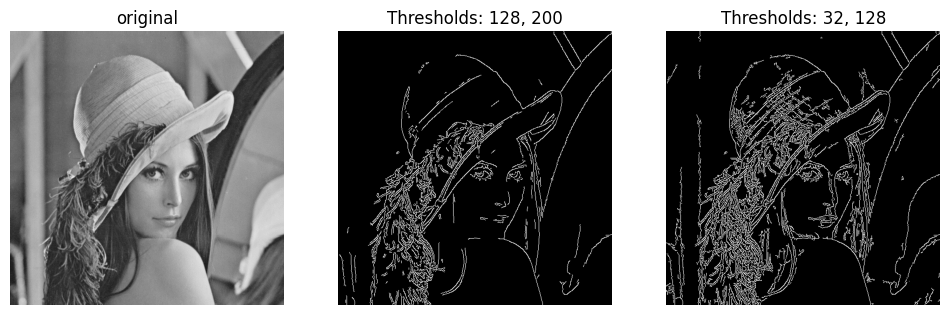

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
o = cv2.imread("lena.bmp", cv2.IMREAD_GRAYSCALE)
r1 = cv2.Canny(o, 128, 200)
r2 = cv2.Canny(o, 32, 128)  # 更低的阈值会检测出更多的边缘

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
r1 = cv2.cvtColor(r1, cv2.COLOR_BGR2RGB)
r2 = cv2.cvtColor(r2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(132)
plt.imshow(r1)
plt.title("Thresholds: 128, 200")
plt.axis("off")
plt.subplot(133)
plt.imshow(r2)
plt.title("Thresholds: 32, 128")
plt.axis("off")
plt.show()